# Global Power Plant Database - Solution Notebook

Ce notebook résout l'ensemble des exercices demandés avec Pandas, NumPy, Matplotlib, Seaborn et SciPy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize']=(10,6)
sns.set_theme()

## 1. Data Import and Cleaning

In [2]:
df = pd.read_csv('data/global_power_plant_database.csv')
df.head()

/var/folders/hq/wqwzmqh53mx_hqlw2tl75b9c0000gn/T/ipykernel_11210/2616424033.py:1: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [3]:
print(df.info())
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [4]:
# Conversion numérique
numeric_cols = ['capacity_mw','latitude','longitude','commissioning_year']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputation simple
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

## 2. Exploratory Data Analysis

In [5]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,34936.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,2002.213173,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,17.215166,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,2007.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2007.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [6]:
country_counts = df['country_long'].value_counts().head(10)
fuel_counts = df['primary_fuel'].value_counts()

print(country_counts)
print(fuel_counts.head())

country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Name: count, dtype: int64
primary_fuel
Solar    10665
Hydro     7156
Wind      5344
Gas       3998
Coal      2330
Name: count, dtype: int64


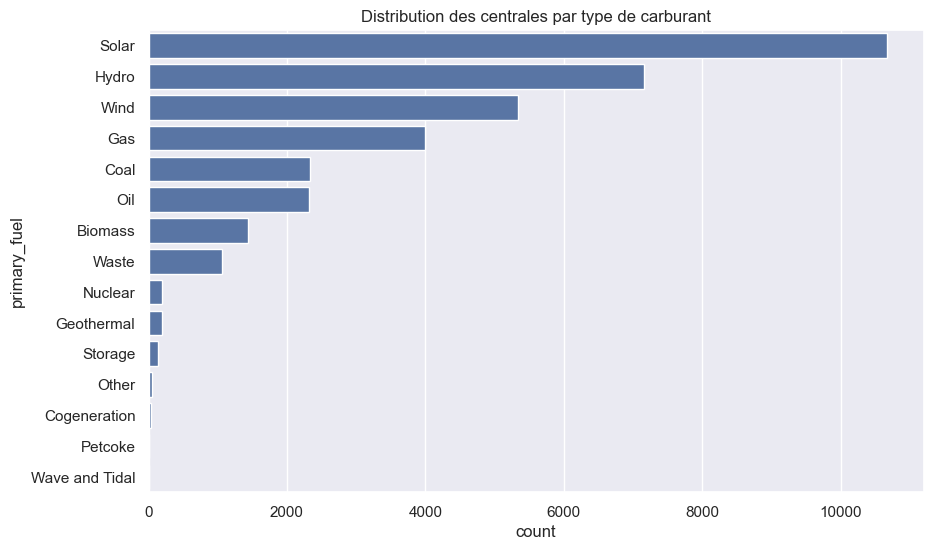

In [7]:
sns.countplot(data=df, y='primary_fuel', order=df['primary_fuel'].value_counts().index)
plt.title('Distribution des centrales par type de carburant')
plt.show()

## 3. Statistical Analysis

In [8]:
fuel_stats = df.groupby('primary_fuel')['capacity_mw'].agg(['mean','median','std'])
fuel_stats

,mean,median,std
primary_fuel,,,
Biomass,23.972938,9.45000,39.461805
Coal,843.579828,600.00000,888.187187
Cogeneration,98.731707,31.90000,283.428252
Gas,373.449375,147.50000,560.934146
Geothermal,67.130952,30.00000,114.640890
Hydro,147.171551,20.00000,549.809328
Nuclear,2091.855179,1888.00000,1303.509273
Oil,112.878754,9.00000,392.009039
Other,84.020000,40.00000,145.891392


In [10]:
# Exemple de test t entre Coal et Gas
coal = df[df['primary_fuel']=='Coal']['capacity_mw'].dropna()
gas = df[df['primary_fuel']=='Gas']['capacity_mw'].dropna()

t_stat, p_value = stats.ttest_ind(coal, gas, equal_var=False)
print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: 23.014807330180812
P-value: 4.104002519246407e-109


## 4. Time Series Analysis

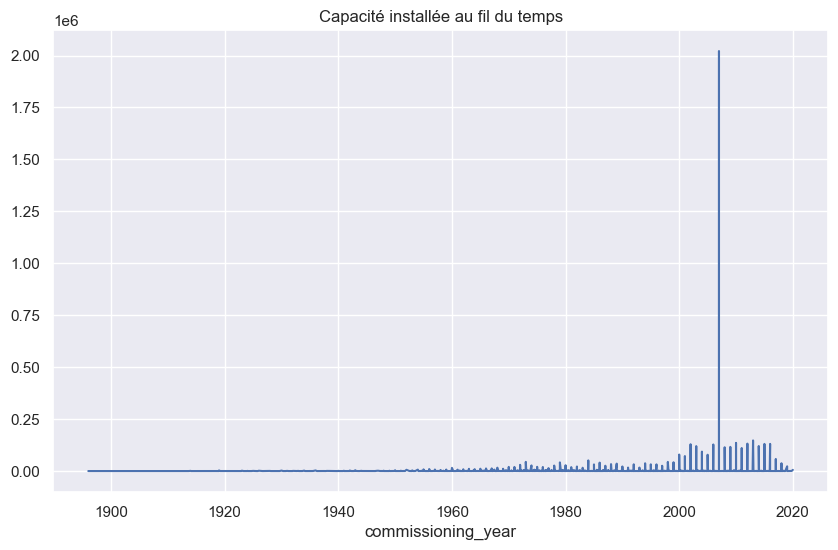

In [11]:
yearly_capacity = df.groupby('commissioning_year')['capacity_mw'].sum()
yearly_capacity.plot()
plt.title('Capacité installée au fil du temps')
plt.show()

In [12]:
fuel_year = pd.crosstab(df['commissioning_year'], df['primary_fuel'])
fuel_year.tail()

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,
2019.000000,2,0,1,34,2,1,0,2,0,0,458,32,3,0,61
2019.000000,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2019.411765,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2019.796326,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2020.000000,1,0,0,6,0,0,0,0,0,0,122,2,2,0,17


## 5. Advanced Visualization

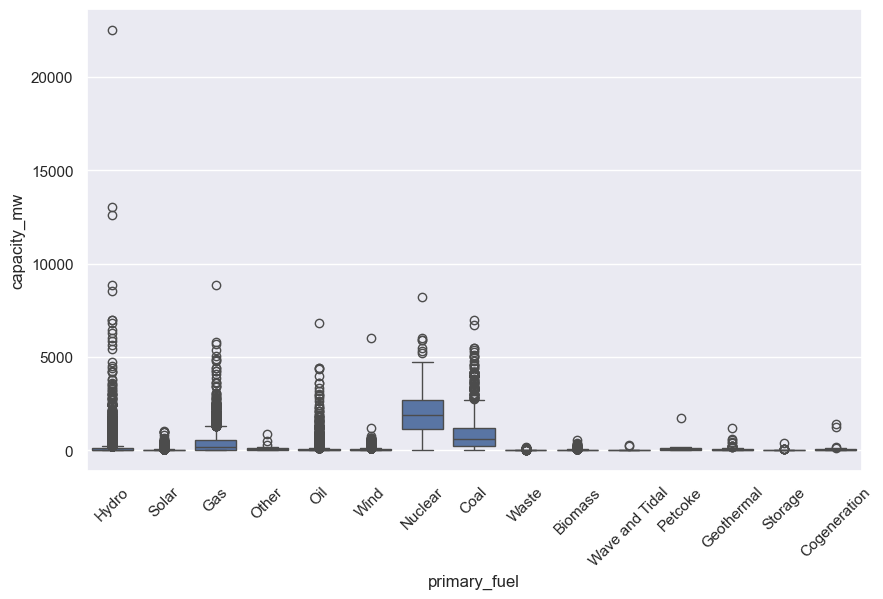

In [13]:
sns.boxplot(data=df, x='primary_fuel', y='capacity_mw')
plt.xticks(rotation=45)
plt.show()

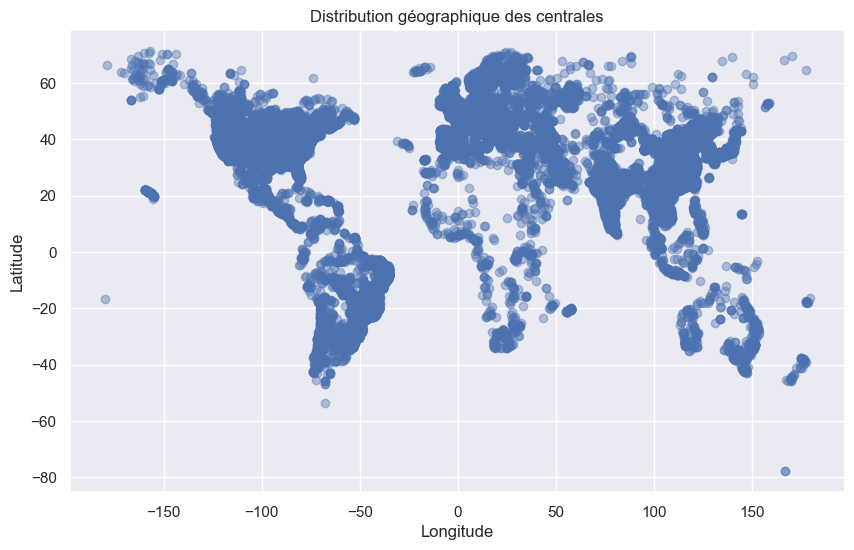

In [14]:
plt.scatter(df['longitude'], df['latitude'], alpha=0.4)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribution géographique des centrales')
plt.show()

## 6. Matrix Operations

In [15]:
matrix_cols = ['capacity_mw','latitude','longitude']
matrix_df = df[matrix_cols].dropna()

corr_matrix = np.corrcoef(matrix_df.T)
print(corr_matrix)

eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)
print('Eigenvalues:', eigenvalues)
print('Eigenvectors:', eigenvectors)

[[ 1.         -0.01321759  0.15152454]
 [-0.01321759  1.         -0.06835441]
 [ 0.15152454 -0.06835441  1.        ]]
Eigenvalues: [1.17147434 0.83840686 0.9901188 ]
Eigenvectors: [[-0.63986801  0.65138323  0.40776072]
 [ 0.32661662 -0.24978272  0.91155372]
 [-0.69562239 -0.7164555   0.05292462]]


Les valeurs propres (eigenvalues) mesurent l'importance des composantes principales.
Les vecteurs propres (eigenvectors) indiquent les directions principales de variation des données.

## 7. NumPy + Pandas + Matplotlib

In [16]:
mask = np.logical_and(df['capacity_mw'] > np.percentile(df['capacity_mw'],75),
                          df['latitude'] > 0)

filtered_df = df[mask]
filtered_df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
10,ALB,Albania,Fierza,WRI1002170,500.0,42.2514,20.0431,Hydro,NaN,NaN,...,1976.01,1276.61,1503.72,1795.15,1648.24,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
11,ALB,Albania,Koman,WRI1002171,600.0,42.1033,19.8224,Hydro,NaN,NaN,...,2072.13,1618.73,1805.63,2434.84,1982.72,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
15,ALB,Albania,Vau i Dijes,WRI1002175,250.0,42.0137,19.6359,Hydro,NaN,NaN,...,895.02,561.94,614.47,897.47,703.64,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
16,ALB,Albania,Vlora,WRI1002176,98.0,40.4874,19.4340,Other,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION


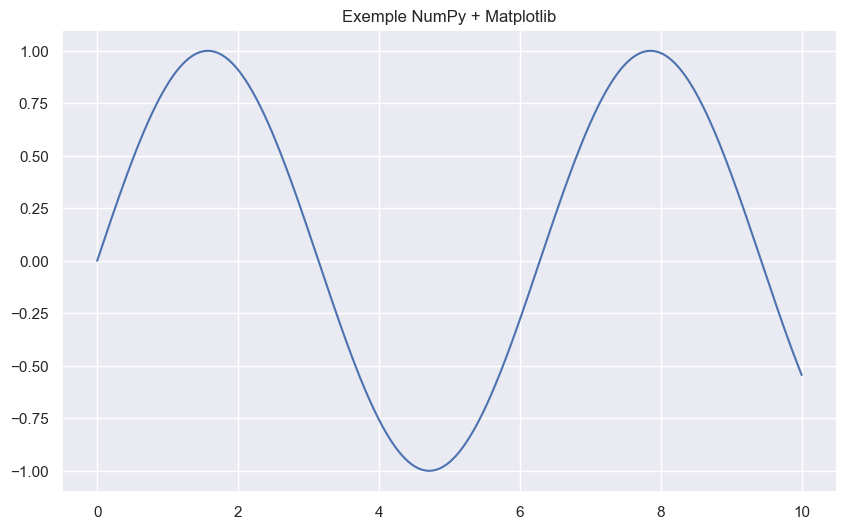

In [17]:
x = np.linspace(0, 10, 500)
y = np.sin(x)

plt.plot(x,y)
plt.title('Exemple NumPy + Matplotlib')
plt.show()